No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


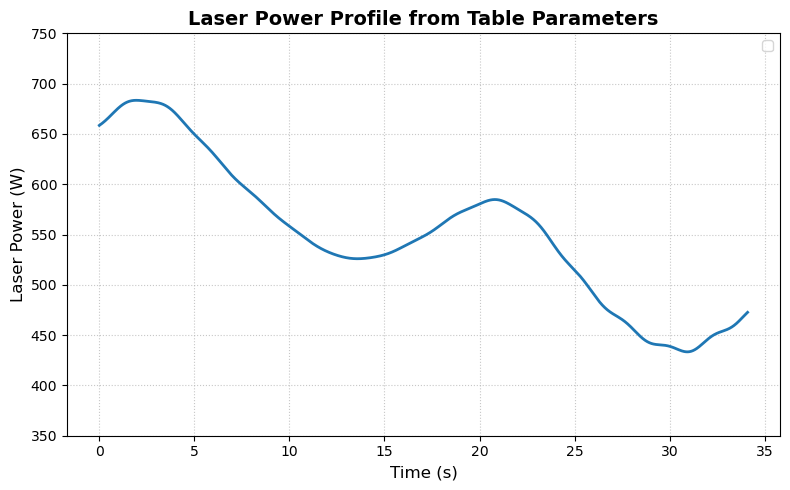

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Physical parameters straight from your table
params = {
    'decay_rate': 1.00,        # Number of Terms of Fourier (n)
    'freq': 1.60,              # Frequency of Fourier (f)
    'amplitude_watts': 6.89,   # Amplitude of Fourier (A)
    'phase': 0.71,             # Phase Shift of Fourier (phi)
    'trend_watts': -90.0,      # Linear Trend Coefficient (T)
    'seasonality_watts': 45.0, # Seasonality Amplitude (S)
    'freq_slope': -0.27,       # Rates of Change for Frequency (Δf)
    'amp_slope': 0.57,         # Rates of Change for Amplitude (ΔA)
    'phase_slope': -0.85,      # Rates of Change for Phase Shift (Δphi)
    'seasonality_freq': 0.94   # Frequency of Seasonality (SF)
}

# 2. Simulation Setup
total_time = 34.1
time_step = 0.002
time_array = np.arange(0, total_time, time_step)
x_norm = 2 * (time_array / total_time) - 1  # Normalized time [-1, 1]

# 3. Base Fourier Series Generation
sum_val = np.zeros_like(x_norm)
num_terms = 5 
for i in range(1, num_terms * 2, 2):
    term_weight = (1 / (i ** params['decay_rate']))
    term = term_weight * np.sin(2 * np.pi * (params['freq'] + i * params['freq_slope']) * i * x_norm + (params['phase'] + i * params['phase_slope']))
    sum_val += term

# Normalize the Fourier sum to [-1, 1] so amplitude applies cleanly
if np.max(sum_val) != np.min(sum_val):
    sum_val = sum_val / np.max(np.abs(sum_val))

# 4. Assemble Physical Profile (Baseline + Waves + Trend + Seasonality)
baseline_power = 550.0 
y = baseline_power + (sum_val * (params['amplitude_watts'] + (x_norm * params['amp_slope'] * 50)))
y += params['trend_watts'] * x_norm
y += params['seasonality_watts'] * np.sin(2 * np.pi * params['seasonality_freq'] * x_norm)

# Hardware Safety Clipping
power_array = np.clip(y, 400, 700)

# 5. Plotting
plt.figure(figsize=(8, 5))
plt.plot(time_array, power_array, color='#1f77b4', linewidth=2)
plt.title("Laser Power Profile from Table Parameters", fontsize=14, fontweight='bold')
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Laser Power (W)", fontsize=12)
# plt.axhline(550, color='gray', linestyle='--', alpha=0.5, label="Baseline (550W)")
plt.ylim(350, 750)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

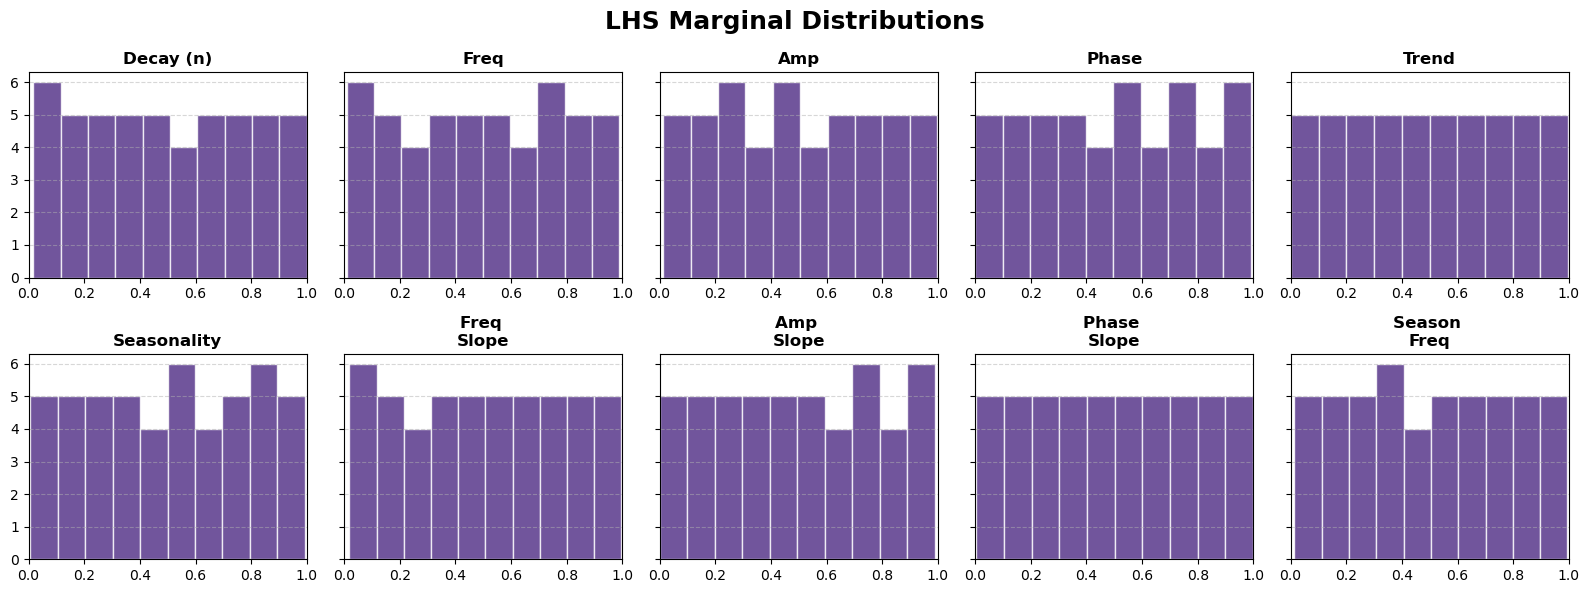

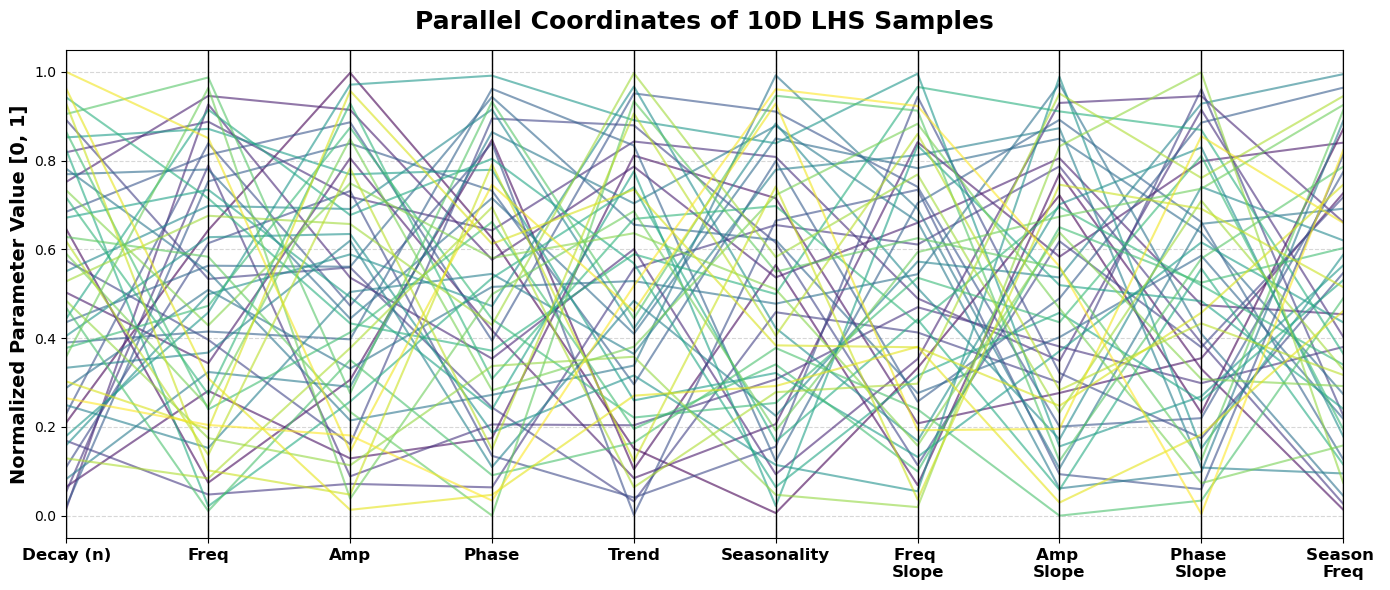

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc

# --- SETUP ---
NUM_PARAMS = 10
NUM_SAMPLES = 50 
sampler = qmc.LatinHypercube(d=NUM_PARAMS)
sample_points = sampler.random(n=NUM_SAMPLES)

# Parameter names based on your Fourier generator
param_names = [
    'Decay (n)', 'Freq', 'Amp', 'Phase', 'Trend', 
    'Seasonality', 'Freq \nSlope', 'Amp \nSlope', 'Phase \nSlope', 'Season \nFreq'
]

# Convert to a DataFrame for easy plotting
df = pd.DataFrame(sample_points, columns=param_names)

# --- PLOT 1: MARGINAL DISTRIBUTIONS ---
# This proves LHS distributes points evenly across each individual parameter
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharey=True)
fig.suptitle('LHS Marginal Distributions', fontsize=18, fontweight='bold')

for i, col in enumerate(df.columns):
    ax = axes[i//5, i%5]
    # Using the presentation purple!
    ax.hist(df[col], bins=10, color='#4E2A84', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("LHS_Histograms_Presentation.png", dpi=300)
plt.show()

# --- PLOT 2: PARALLEL COORDINATES ---
# This shows how the 50 distinct samples traverse the 10-dimensional space
plt.figure(figsize=(14, 6))
pd.plotting.parallel_coordinates(
    df.assign(Sample_ID=df.index), 
    'Sample_ID', 
    colormap='viridis', 
    alpha=0.6
)

plt.title("Parallel Coordinates of 10D LHS Samples", fontsize=18, fontweight='bold', pad=15)
plt.ylabel("Normalized Parameter Value [0, 1]", fontsize=14, fontweight='bold')
plt.gca().legend_.remove() # Remove the legend (it's just 50 sample IDs)
plt.xticks(fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("LHS_Parallel_Coordinates.png", dpi=300)
plt.show()

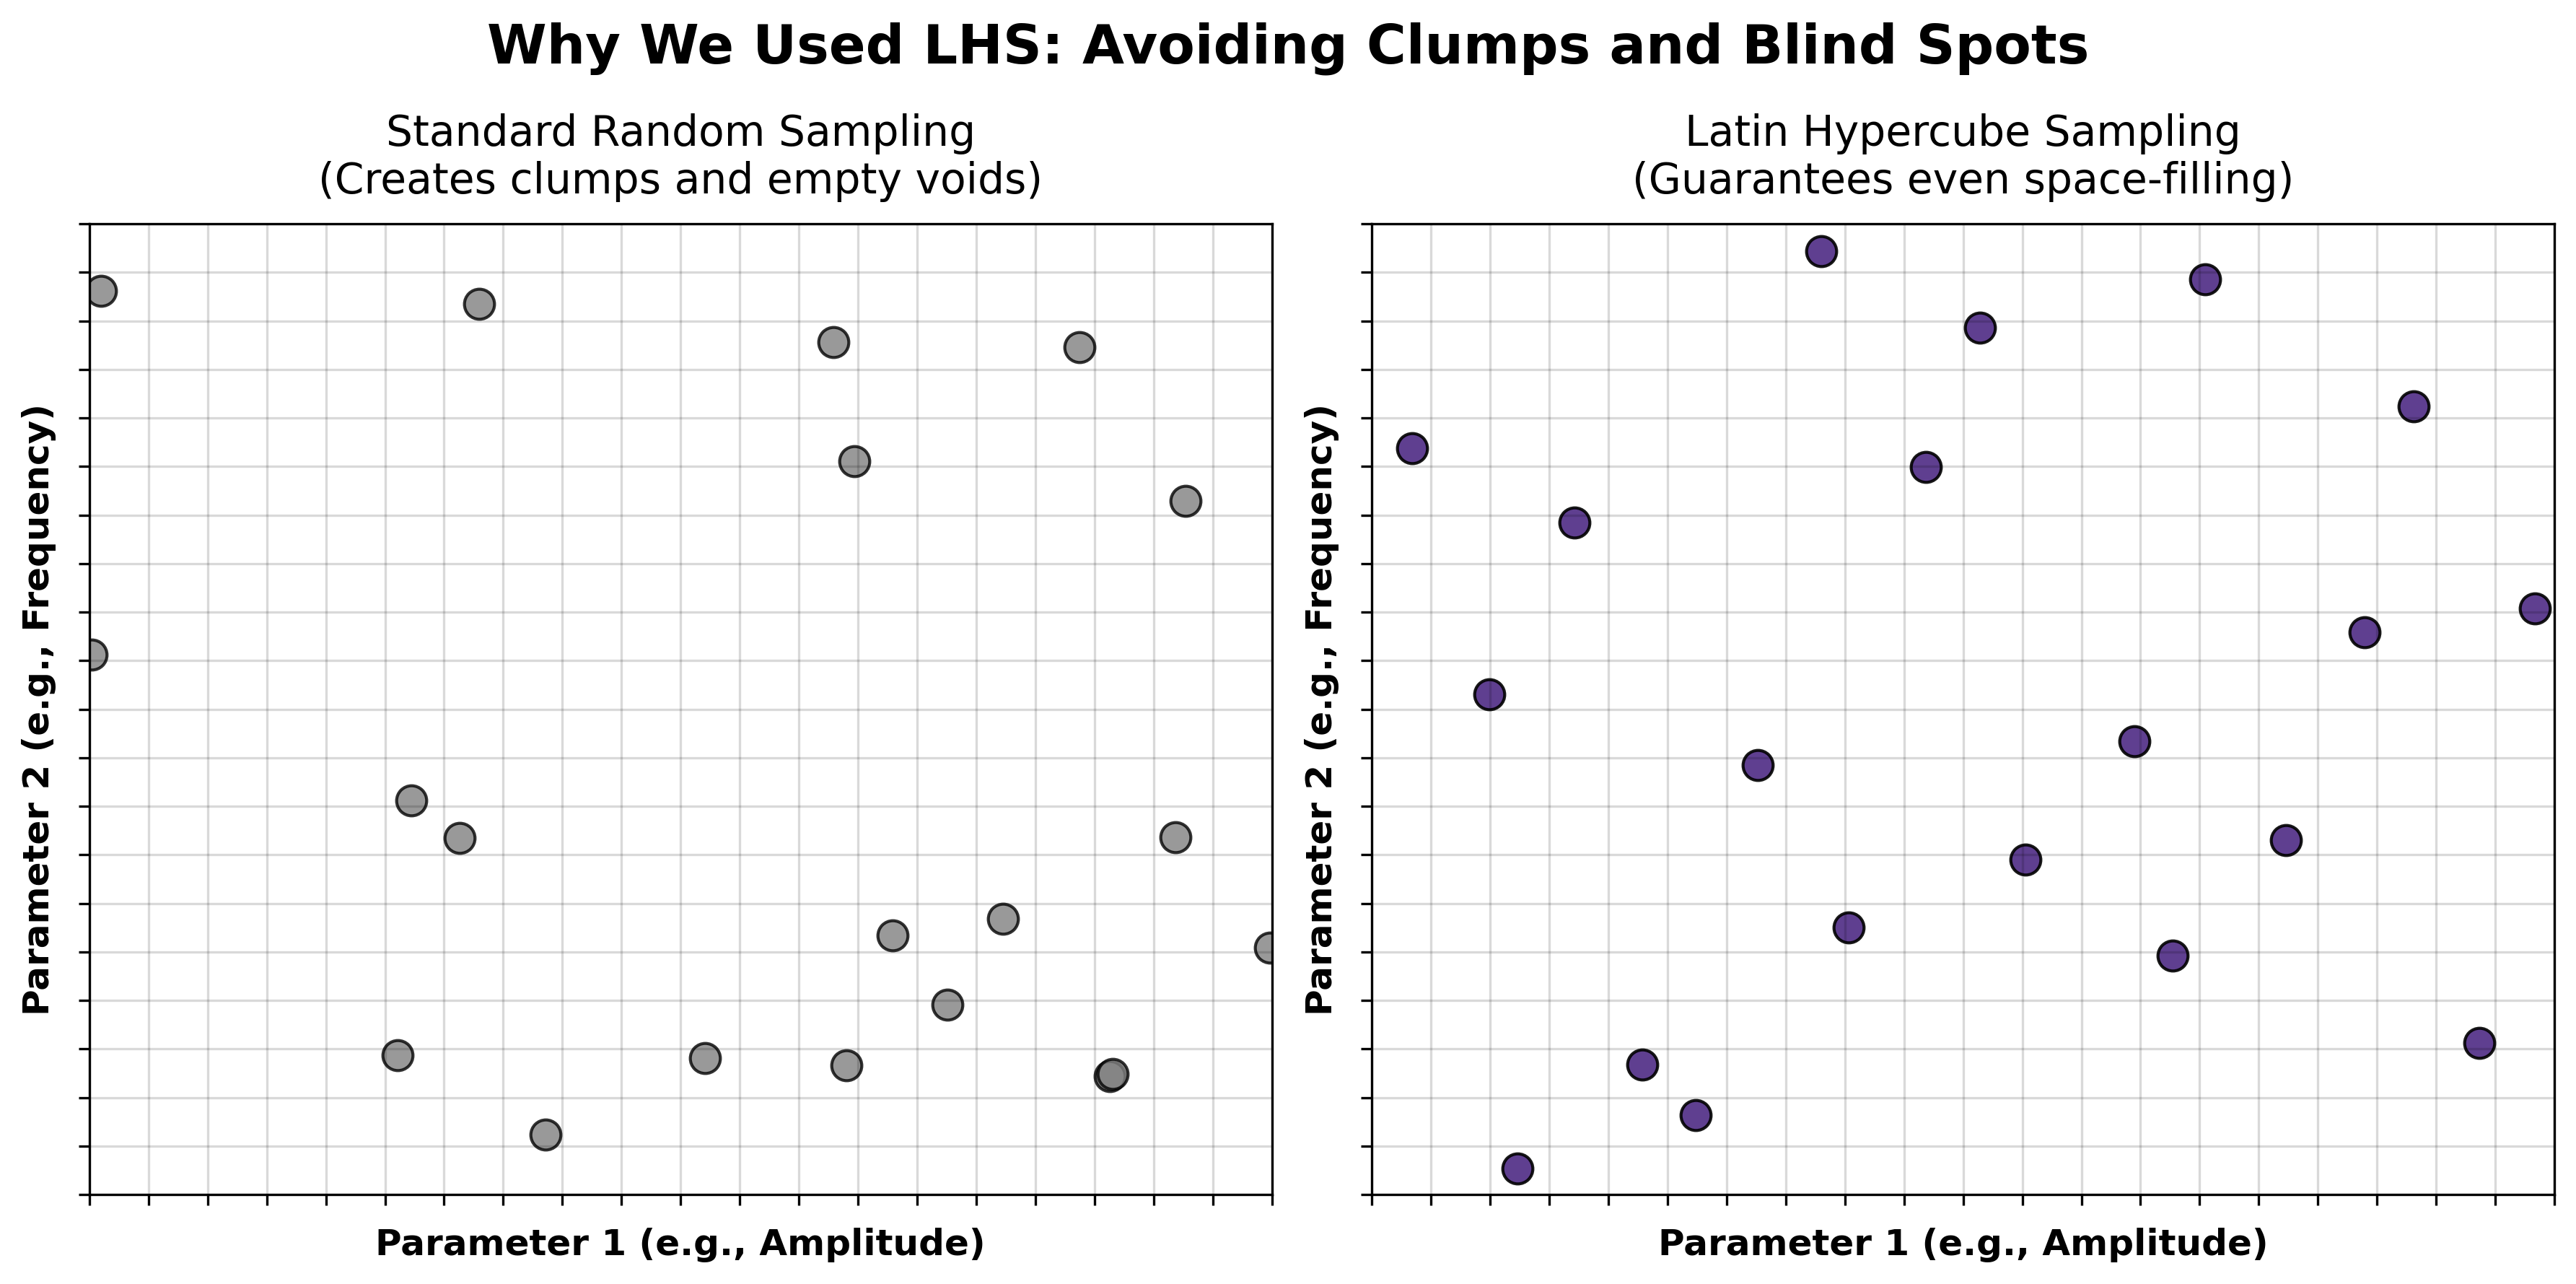

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

# Setup a small number of samples purely to make the grid visually obvious
N_SAMPLES = 20

# 1. Standard Random Sampling (Monte Carlo)
random_sampler = np.random.rand(N_SAMPLES, 2)

# 2. Latin Hypercube Sampling (LHS)
lhs_sampler = qmc.LatinHypercube(d=2).random(n=N_SAMPLES)

# --- PRESENTATION PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), dpi=300)
fig.suptitle('Why We Used LHS: Avoiding Clumps and Blind Spots', fontsize=18, fontweight='bold', y=0.98)

# Plot Standard Random
ax1.scatter(random_sampler[:, 0], random_sampler[:, 1], color='gray', s=100, alpha=0.8, edgecolor='black')
ax1.set_title("Standard Random Sampling\n(Creates clumps and empty voids)", fontsize=14, pad=10)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# Plot LHS
# Using your presentation purple!
ax2.scatter(lhs_sampler[:, 0], lhs_sampler[:, 1], color='#4E2A84', s=100, alpha=0.9, edgecolor='black')
ax2.set_title("Latin Hypercube Sampling\n(Guarantees even space-filling)", fontsize=14, pad=10)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

# Add grid lines to visually explain the LHS "bins"
for ax in [ax1, ax2]:
    # Create a grid with the same number of bins as samples
    ax.set_xticks(np.linspace(0, 1, N_SAMPLES + 1))
    ax.set_yticks(np.linspace(0, 1, N_SAMPLES + 1))
    ax.grid(True, color='black', linestyle='-', alpha=0.15)
    
    # Hide tick numbers to keep the slide clean
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    
    ax.set_xlabel("Parameter 1 (e.g., Amplitude)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Parameter 2 (e.g., Frequency)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("LHS_vs_Random_Presentation.png", dpi=300)
plt.show()

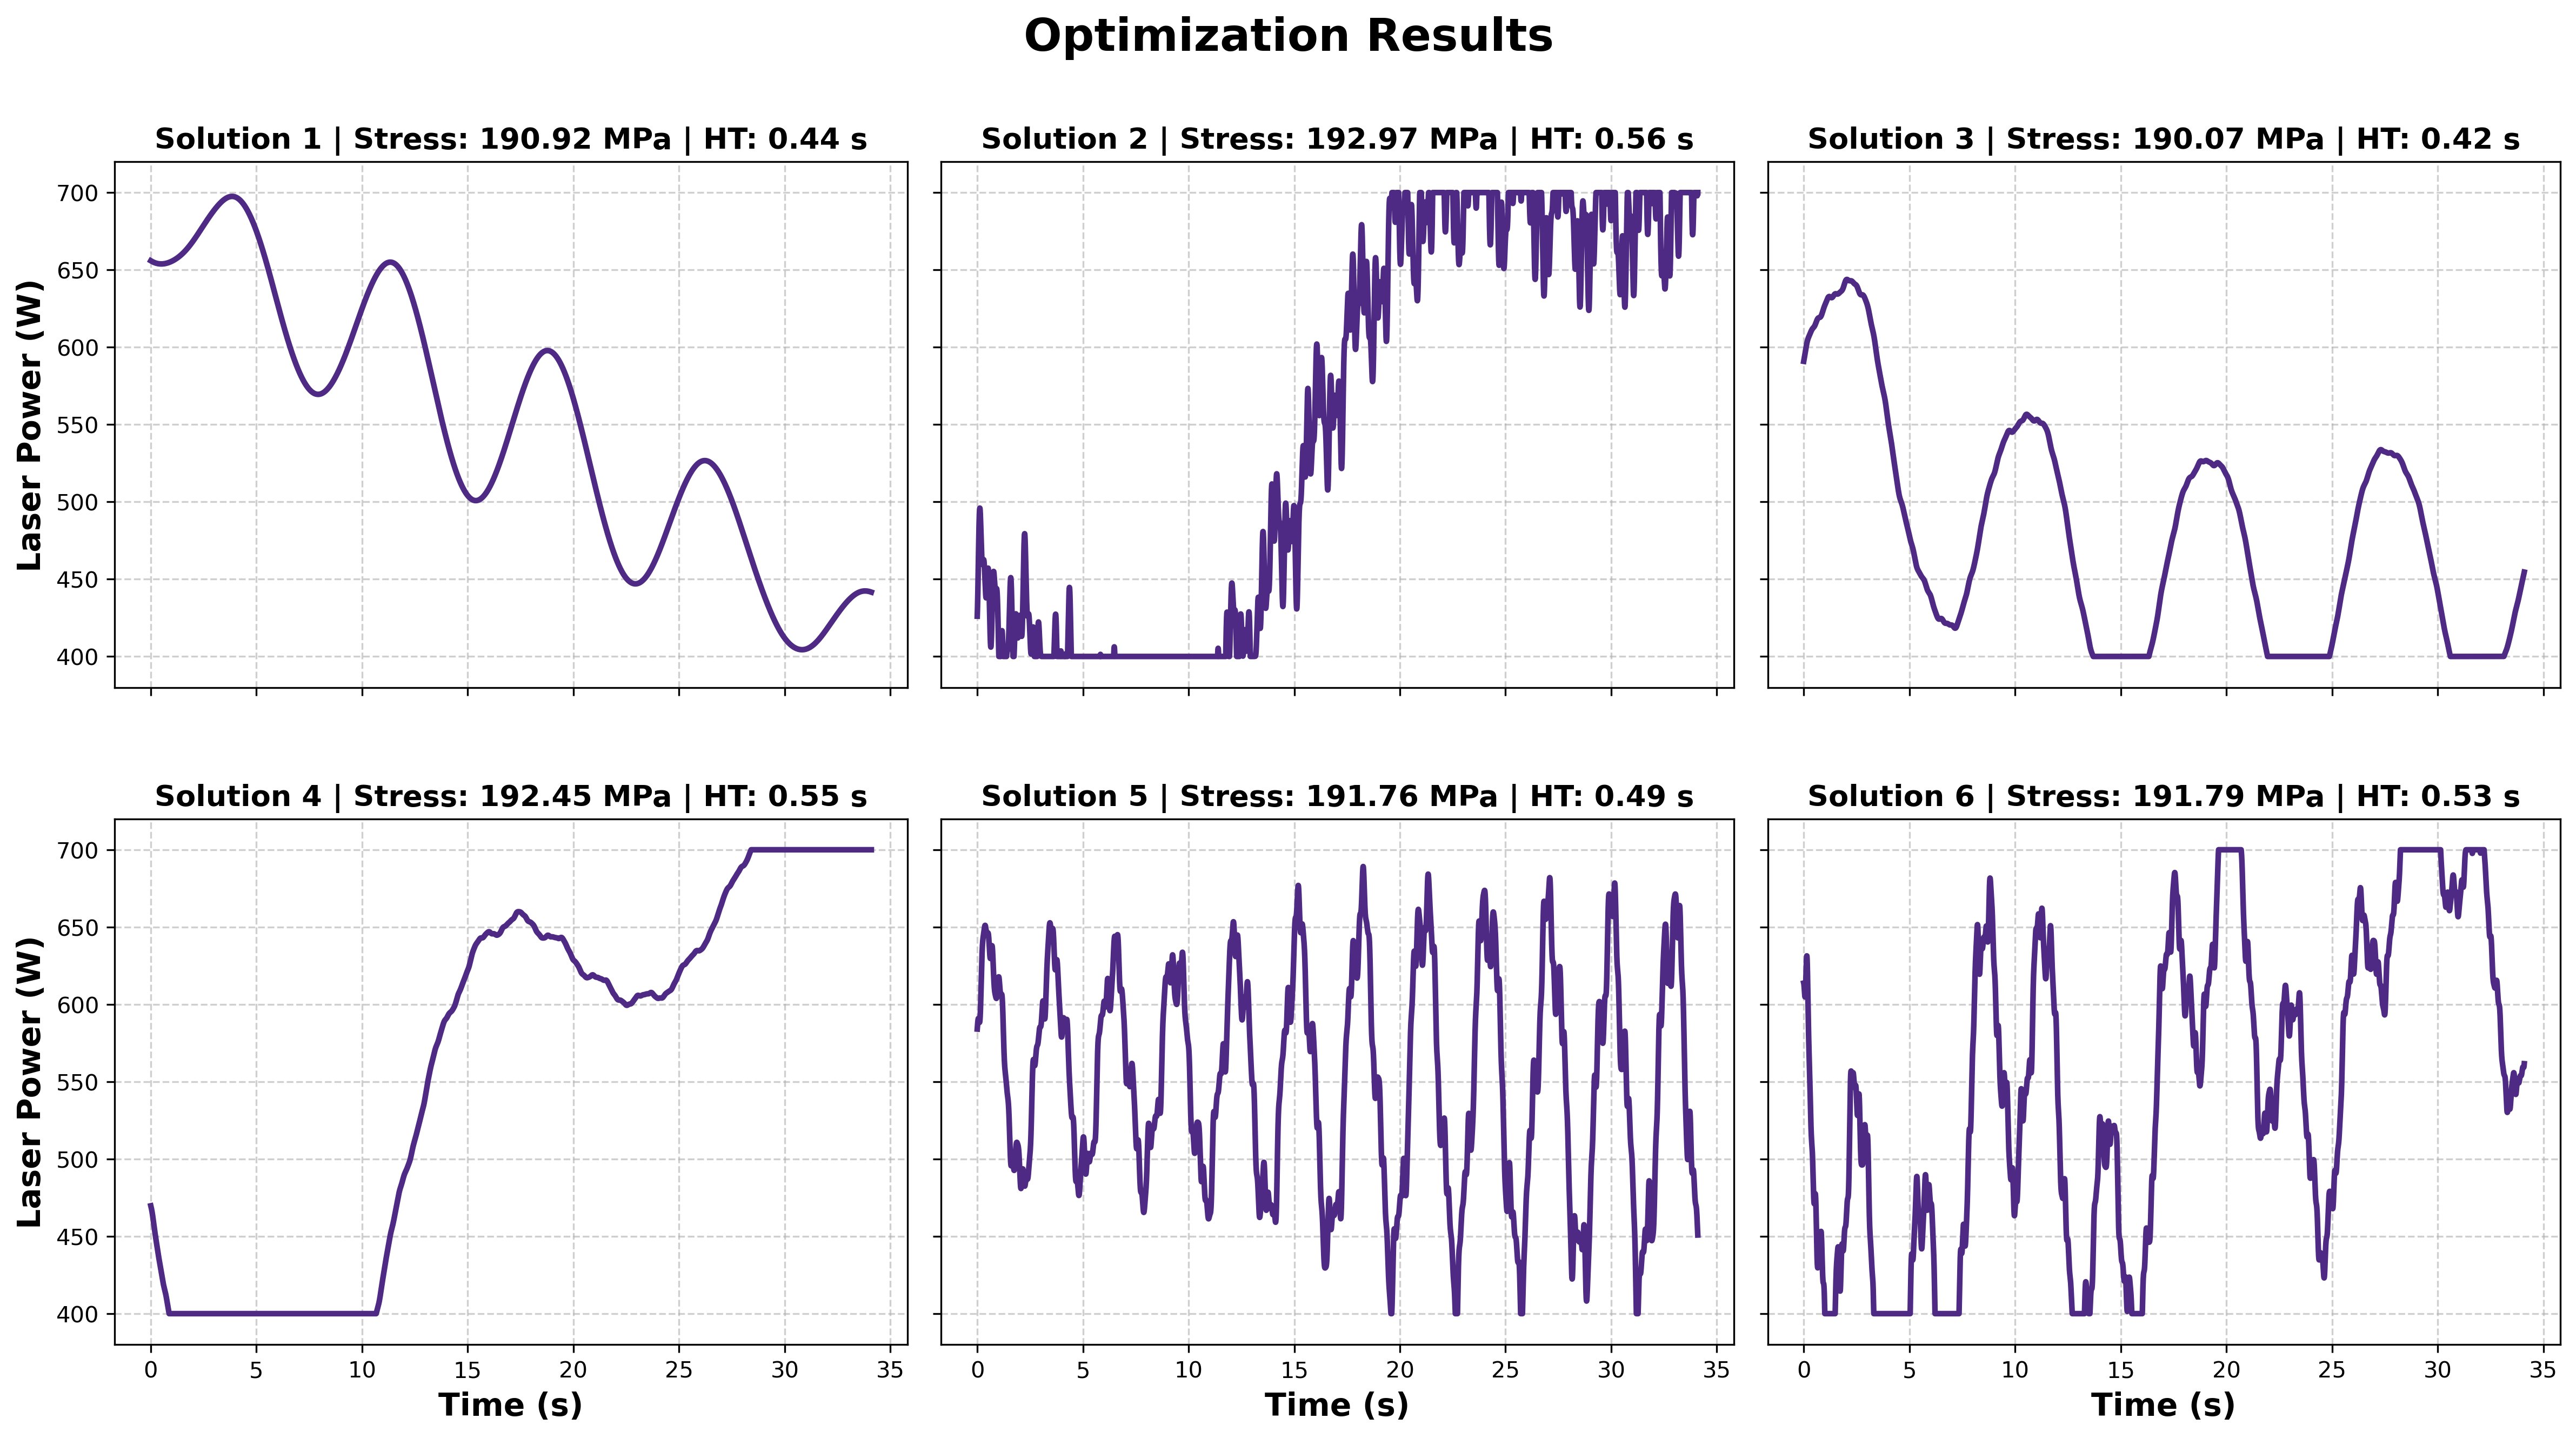

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np

class LaserProfileGenerator:
    def __init__(self, total_time=300, time_step=0.002):
        self.total_time = total_time
        self.time_step = time_step
        
        # Placeholders for the pre-calculated arrays
        self.time_array = None
        self.power_array = None

    def _normalize_time(self, x):
        """
        Normalize the time array to [-1, 1] based on total simulation duration.
        """
        return 2 * (x / self.total_time) - 1

    def _rescale(self, x, min_value, max_value):
        """Rescale a normalized input [0, 1] to physical range [min, max]."""
        return x * (max_value - min_value) + min_value

    def generate_profile(self, params, min_power=400, max_power=700):
        """
        Maps normalized BO parameters to physical laser outputs.
        """
        self.time_array = np.arange(0, self.total_time, self.time_step)
        x_norm = self._normalize_time(self.time_array)

        # Unpack params
        n, freq, amplitude, phase, trend, seasonality, frequency_slope, amplitude_slope, phase_slope, seasonality_freq = params
        
        # 1. Map to continuous physical constraints
        # Smooth exponential decay for Fourier terms is much better for BO than an int cutoff
        decay_rate = self._rescale(n, 0.5, 3.0) 
        
        freq = self._rescale(freq, 0.1, 10.0)
        amplitude_watts = self._rescale(amplitude, 0, 150) # Actual physical Watts!
        phase = self._rescale(phase, 0, 2 * np.pi)
        
        trend_watts = self._rescale(trend, -150, 150)
        seasonality_watts = self._rescale(seasonality, 0, 100)
        
        frequency_slope = self._rescale(frequency_slope, -1.0, 1.0)
        amplitude_slope = self._rescale(amplitude_slope, -1.0, 1.0)
        phase_slope = self._rescale(phase_slope, -1.0, 1.0)
        seasonality_freq = self._rescale(seasonality_freq, 0.5, 5.0)

        # 2. Base Fourier Series (Continuous, no integer dead-zones)
        sum_val = np.zeros_like(x_norm)
        num_terms = 5 # Fixed number of terms, but their power decays based on 'n' parameter
        for i in range(1, num_terms * 2, 2):
            # 'decay_rate' smoothly controls how much high-frequency noise is in the signal
            term_weight = (1 / (i ** decay_rate)) 
            term = term_weight * np.sin(2 * np.pi * (freq + i * frequency_slope) * i * x_norm + (phase + i * phase_slope))
            sum_val += term

        # 3. Assemble Physical Profile
        # Center the baseline exactly in the middle of your safe zone (550W)
        baseline_power = 550.0 
        
        # Scale the normalized sum exactly to the requested amplitude in Watts
        if np.max(sum_val) != np.min(sum_val):
            sum_val = sum_val / np.max(np.abs(sum_val)) # Normalize to [-1, 1]
            
        y = baseline_power + (sum_val * (amplitude_watts + (x_norm * amplitude_slope * 50)))
        
        # Add Trend and Seasonality in absolute Watts
        y += trend_watts * x_norm
        y += seasonality_watts * np.sin(2 * np.pi * seasonality_freq * x_norm)

        # 4. Hardware Safety Clipping (Does not stretch/distort the wave)
        self.power_array = np.clip(y, min_power, max_power)
        
    def get_power_at_time(self, t):
        """
        Fetches the power at a specific scalar time 't' using linear interpolation.
        """
        if self.time_array is None or self.power_array is None:
            raise RuntimeError("You must call generate_profile(params) before fetching power.")
        
        # np.interp handles scalar 't' perfectly, even if 't' falls between exact time_steps
        return np.interp(t, self.time_array, self.power_array)


# ==========================================
# 2. YOUR 6 SOLUTIONS
# ==========================================
solution_1 = [0.8318, 0.2782, 0.0149, 0.9162, 0.0519, 0.6268, 0.2721, 0.1126, 0.0628, 0.3725]
solution_2 = [0.0,    0.0,    0.7681, 0.2188, 1.0,    1.0,    0.0,    0.6773, 1.0,    0.0]
solution_3 = [0.8419, 0.0555, 0.7258, 0.857,  0.1986, 0.8636, 0.0684, 0.0852, 0.0903, 0.3348]
solution_4 = [1.0,    0.0,    0.8583, 0.0,    1.0,    1.0,    0.0,    0.0,    1.0,    0.0]
solution_5 = [0.3605, 0.4987, 0.9241, 0.0,    0.4557, 0.1245, 0.8735, 0.9608, 0.063,  1.0]
solution_6 = [0.3805, 0.4755, 0.7999, 1.0,    0.9598, 1.0,    1.0,    0.0,    1.0,    0.278]

pareto_solutions = [solution_1, solution_2, solution_3, solution_4, solution_5, solution_6]

# Corresponding performance metrics for the subplot titles
# Format: (Avg Stress, Avg Heat Treatment)
metrics = [
    (190.92, 0.44), 
    (192.97, 0.56), 
    (190.07, 0.42), 
    (192.45, 0.55), 
    (191.76, 0.49), 
    (191.79, 0.53)
]

# ==========================================
# 3. PLOTTING THE 2x3 GRID
# ==========================================
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9), dpi=300, sharex=True, sharey=True)
fig.suptitle("Optimization Results", fontsize=20, fontweight='bold', y=0.98)

axes = axes.flatten()
generator = LaserProfileGenerator(total_time=34.1)

for i, params in enumerate(pareto_solutions):
    generator.generate_profile(params)
    
    ax = axes[i]
    # Presentation Purple
    ax.plot(generator.time_array, generator.power_array, color='#4E2A84', linewidth=2.5)
    # ax.fill_between(generator.time_array, generator.power_array, 380, color='#4E2A84', alpha=0.15)
    
    # Subplot Formatting with actual physical results
    stress, ht = metrics[i]
    ax.set_title(f"Solution {i+1} | Stress: {stress} MPa | HT: {ht} s", fontsize=13, fontweight='bold')
    
    ax.set_ylim(380, 720) 
    ax.grid(True, linestyle='--', alpha=0.6)
    
    if i >= 3:
        ax.set_xlabel("Time (s)", fontsize=14, fontweight='bold')
        
    if i % 3 == 0:
        ax.set_ylabel("Laser Power (W)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.25) # Gives extra room for titles
plt.savefig("Pareto_Solutions_Grid.png", dpi=300)
plt.show()